# Heart Failure Prediction Using Scikit-learn and Keras

## Objective:
To build and compare machine learning models using Scikit-learn’s MLPClassifier and Keras Sequential API to predict heart failure based on clinical data.


Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, roc_curve

In [ ]:
# For Scikit-learn MLP
from sklearn.neural_network import MLPClassifier

In [ ]:
# For Keras Neural Network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


In [ ]:
# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# --- 1. Dataset Selection and Description ---
print("--- 1. Dataset Selection and Description ---")

# Provide the Kaggle dataset information
dataset_name_main = "Heart Failure Prediction Dataset"
dataset_name_additional = "Predict heart failure from clinical records"
dataset_link = "https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction"
dataset_owner = "Fedesoriano (Federico Soriano)"

print(f"Using dataset: {dataset_name_main}")
print(f"Link: {dataset_link}")
print(f"Owner: {dataset_owner}\n")


--- 1. Dataset Selection and Description ---
Using dataset: Heart Failure Prediction Dataset
Link: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
Owner: Fedesoriano (Federico Soriano)



Dataset loading and description

Information about the selected dataset is provided.

Basic information about the data is displayed: first rows, data types, statistical description, and missing value checking.

In [ ]:
# Load the dataset
try:
    df = pd.read_csv('/content/heart.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'heart.csv' not found. Please upload the dataset to your Kaggle environment.")
    raise

print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset information:")
df.info()

print("\nDataset description (statistical summary):")
print(df.describe().transpose())

print("\nChecking for missing values:")
print(df.isnull().sum())

Dataset loaded successfully.

First 5 rows of the dataset:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


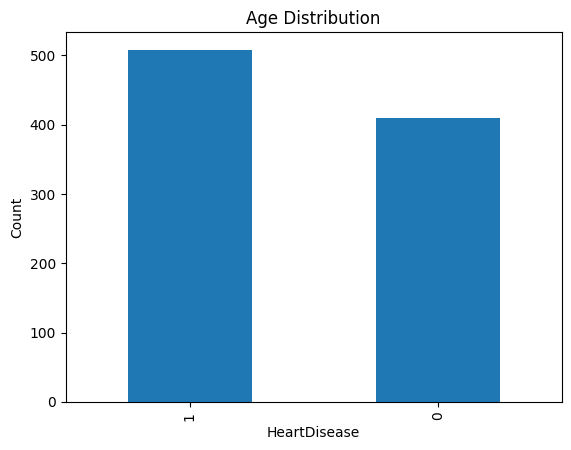

In [ ]:
# Basic info
df.info()

# Check for missing values
df.isnull().sum()

# Class distribution
df['HeartDisease'].value_counts().plot(kind='bar', title='Class Distribution')

# Optional: visualize feature distributions
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()


Data Visualization

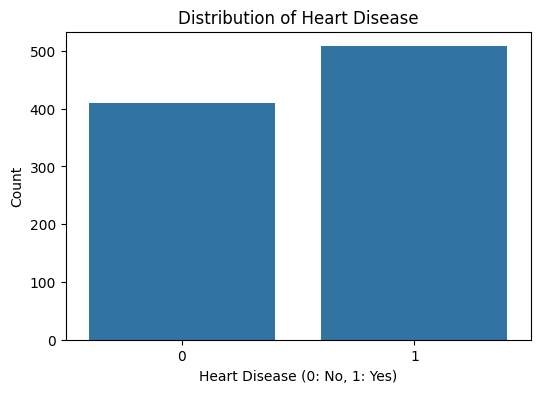

Plot 1: Distribution of the target variable 'HeartDisease'. This shows the balance of classes.


In [ ]:

# Distribution of the target variable 'HeartDisease'
plt.figure(figsize=(6, 4))
sns.countplot(x='HeartDisease', data=df)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()
print("Plot 1: Distribution of the target variable 'HeartDisease'. This shows the balance of classes.")

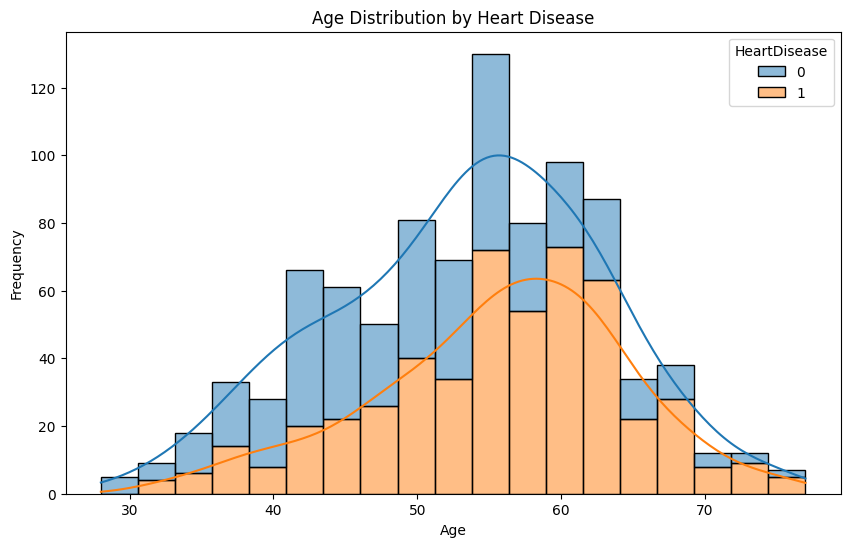

Plot 2: Age distribution for patients with and without heart disease.


In [ ]:
# Age distribution by Heart Disease
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='HeartDisease', kde=True, multiple="stack")
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
print("Plot 2: Age distribution for patients with and without heart disease.")


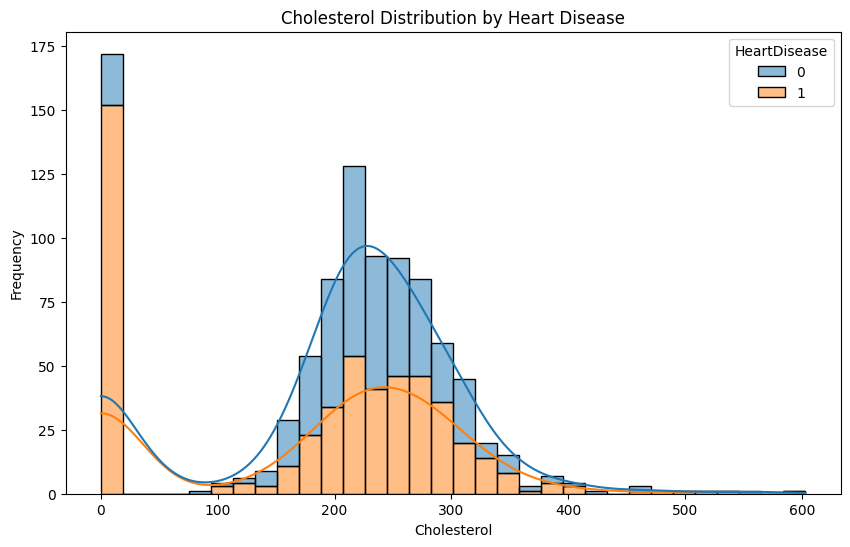

Plot 3: Cholesterol distribution. Note: 0 values for cholesterol might need special attention or indicate missing data recorded as 0.


In [ ]:
# Cholesterol distribution by Heart Disease
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Cholesterol', hue='HeartDisease', kde=True, multiple="stack")
plt.title('Cholesterol Distribution by Heart Disease')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')
plt.show()
print("Plot 3: Cholesterol distribution. Note: 0 values for cholesterol might need special attention or indicate missing data recorded as 0.")


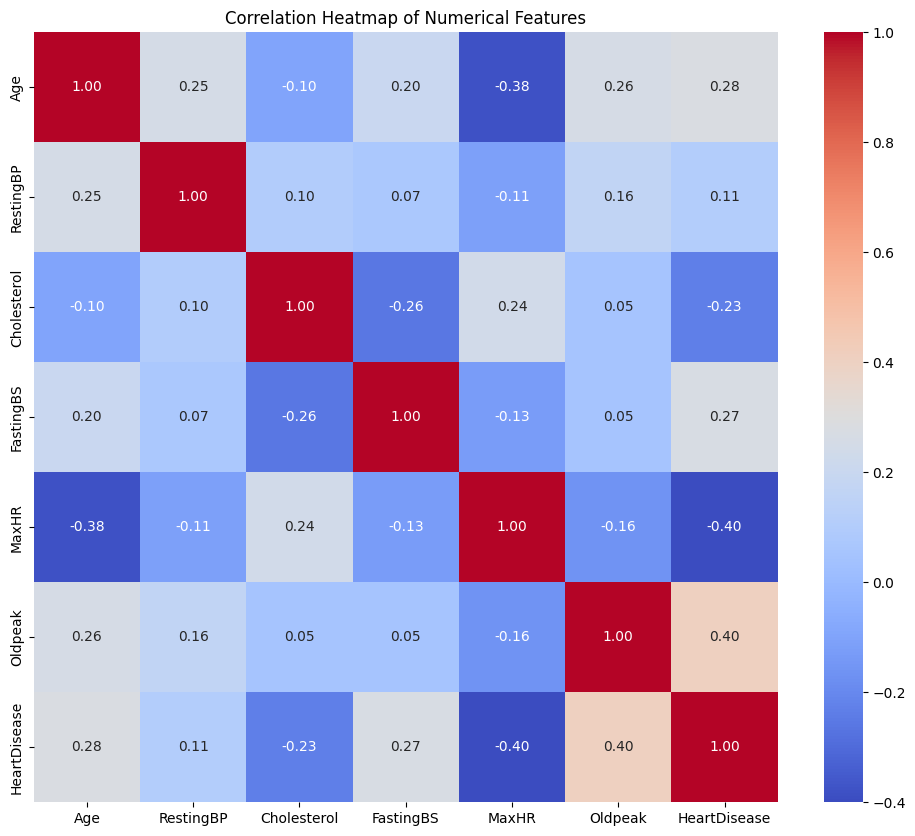

Plot 4: Correlation heatmap to understand relationships between numerical features.

The dataset does not contain explicit geographical data, so a map is not generated.


In [ ]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
# Select only numeric columns for correlation matrix if not done by corr() automatically
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()
print("Plot 4: Correlation heatmap to understand relationships between numerical features.")

# Since there's no explicit geographical data, a map is not applicable for this dataset.
print("\nThe dataset does not contain explicit geographical data, so a map is not generated.")

Preprocessing

The features (X) and the target variable (y) are defined.

Categorical and numeric features are identified.

Pipelines are created for preprocessing:
StandardScaler to scale numeric features.
OneHotEncoder to convert categorical features to numeric format.

ColumnTransformer applies appropriate transformations to the appropriate columns.

The data is split into training and test sets (train_test_split). stratify=y is used to ensure equal distribution of classes in the training and test sets, which is important for unbalanced datasets.

In [ ]:
print("\n--- Data Preprocessing ---")

# Define features (X) and target (y)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# For 'FastingBS' which is already 0 or 1, it can be treated as numerical.
# If it were categorical with more values, it would be in categorical_features.

print(f"\nCategorical features: {list(categorical_features)}")
print(f"Numerical features: {list(numerical_features)}")



--- Data Preprocessing ---

Categorical features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical features: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


In [ ]:
# Create preprocessing pipelines for numerical and categorical features
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # sparse_output=False for easier use with dense layers
])

In [ ]:
# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
], remainder='passthrough') # 'passthrough' in case some columns are not explicitly handled, though all should be.

In [ ]:
# Apply the transformations
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding for better interpretability if needed
# This part can be a bit tricky with ColumnTransformer but is useful for understanding features
try:
    # Get feature names after one-hot encoding
    feature_names_out = preprocessor.get_feature_names_out()
    print(f"\nProcessed feature names (total {len(feature_names_out)}): {feature_names_out[:15]}...") # Print first 15
except AttributeError:
    # For older scikit-learn versions, get_feature_names_out might not be available
    # or might work differently. This is a simplified fallback.
    print("\nCould not retrieve all processed feature names easily (depends on scikit-learn version).")
    print(f"Shape of processed X: {X_processed.shape}")



Processed feature names (total 20): ['num__Age' 'num__RestingBP' 'num__Cholesterol' 'num__FastingBS'
 'num__MaxHR' 'num__Oldpeak' 'cat__Sex_F' 'cat__Sex_M'
 'cat__ChestPainType_ASY' 'cat__ChestPainType_ATA'
 'cat__ChestPainType_NAP' 'cat__ChestPainType_TA' 'cat__RestingECG_LVH'
 'cat__RestingECG_Normal' 'cat__RestingECG_ST']...


In [ ]:
# Convert X_processed to a DataFrame (optional, but can be useful for inspection)
# If you couldn't get feature_names_out easily, you might skip creating this DataFrame or use generic names
try:
    X_processed_df = pd.DataFrame(X_processed, columns=feature_names_out)
    print("\nFirst 5 rows of processed X:")
    print(X_processed_df.head())
except NameError: # If feature_names_out was not successfully created
     X_processed_df = pd.DataFrame(X_processed)
     print("\nFirst 5 rows of processed X (generic column names):")
     print(X_processed_df.head())



First 5 rows of processed X:
   num__Age  num__RestingBP  num__Cholesterol  num__FastingBS  num__MaxHR  \
0 -1.433140        0.410909          0.825070       -0.551341    1.382928   
1 -0.478484        1.491752         -0.171961       -0.551341    0.754157   
2 -1.751359       -0.129513          0.770188       -0.551341   -1.525138   
3 -0.584556        0.302825          0.139040       -0.551341   -1.132156   
4  0.051881        0.951331         -0.034755       -0.551341   -0.581981   

   num__Oldpeak  cat__Sex_F  cat__Sex_M  cat__ChestPainType_ASY  \
0     -0.832432         0.0         1.0                     0.0   
1      0.105664         1.0         0.0                     0.0   
2     -0.832432         0.0         1.0                     0.0   
3      0.574711         1.0         0.0                     1.0   
4     -0.832432         0.0         1.0                     0.0   

   cat__ChestPainType_ATA  cat__ChestPainType_NAP  cat__ChestPainType_TA  \
0                     1.0   

In [ ]:

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Number of features after preprocessing: {X_train.shape[1]}")


Shape of X_train: (734, 20)
Shape of X_test: (184, 20)
Shape of y_train: (734,)
Shape of y_test: (184,)
Number of features after preprocessing: 20


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.0005],
    'early_stopping': [True]
}

mlp_grid = GridSearchCV(
    estimator=MLPClassifier(max_iter=500, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

mlp_grid.fit(X_train, y_train)

# Save the best estimator
mlp_sklearn_tuned = mlp_grid.best_estimator_

# Evaluate it
y_pred_grid = mlp_sklearn_tuned.predict(X_test)

# Metrics
print("Best parameters:", mlp_grid.best_params_)
print("Test Accuracy:", accuracy_score(y_test, y_pred_grid))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_grid))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'activation': 'tanh', 'alpha': 0.0001, 'early_stopping': True, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.001}
Test Accuracy: 0.8695652173913043
ROC AUC Score: 0.8656145384983261


Building and Training an MLP with Scikit-learn

An MLPClassifier model from the sklearn
library is built, trained, and evaluated.

Default (or minimally modified) parameters is given first.

Tuned model is then given. This is where you should experiment with parameters such as hidden_layer_sizes, activation, solver, alpha, learning_rate_init, max_iter, etc. to improve accuracy.

In [ ]:
print("\n--- 2. Scikit-learn MLP Classifier ---")

# --- Initial MLP Model (before extensive tuning) ---
mlp_sklearn = MLPClassifier(random_state=42, max_iter=300) # Default parameters, increase max_iter if convergence warnings

print("Training Scikit-learn MLP (initial parameters)...")
mlp_sklearn.fit(X_train, y_train)


--- 2. Scikit-learn MLP Classifier ---
Training Scikit-learn MLP (initial parameters)...


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(max_iter=300, random_state=42)

In [ ]:
# Predictions
y_pred_mlp_sklearn = mlp_sklearn.predict(X_test)
y_prob_mlp_sklearn = mlp_sklearn.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85        82
           1       0.87      0.90      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184

Accuracy: 0.8695652173913043
Precision: 0.8679245283018868
Recall: 0.9019607843137255
F1 Score: 0.8846153846153846
ROC AUC Score: 0.9224055475848876


In [ ]:
# Evaluation
accuracy_mlp_sklearn = accuracy_score(y_test, y_pred_mlp_sklearn)
roc_auc_mlp_sklearn = roc_auc_score(y_test, y_prob_mlp_sklearn)

print(f"\nScikit-learn MLP (Initial) - Accuracy: {accuracy_mlp_sklearn:.4f}")
print(f"Scikit-learn MLP (Initial) - ROC AUC: {roc_auc_mlp_sklearn:.4f}")
print("Scikit-learn MLP (Initial) - Classification Report:")
print(classification_report(y_test, y_pred_mlp_sklearn))
print("Scikit-learn MLP (Initial) - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_mlp_sklearn))


Scikit-learn MLP (Initial) - Accuracy: 0.8424
Scikit-learn MLP (Initial) - ROC AUC: 0.9201
Scikit-learn MLP (Initial) - Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        82
           1       0.85      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184

Scikit-learn MLP (Initial) - Confusion Matrix:
[[66 16]
 [13 89]]


Scikit-learn MLPClassifier Results:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85        82
           1       0.87      0.90      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184

ROC AUC Score: 0.9224055475848876
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Keras MLP Results:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88        82
           1       0.90      0.92      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.90       184
weighted avg       0.90      0.90      0.90       184

ROC AUC Score: 0.9418938307030129


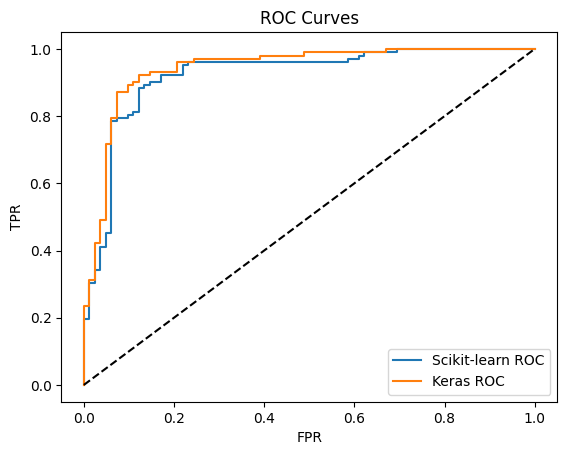

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Scikit-learn Evaluation
y_pred_sk = mlp_sklearn_tuned.predict(X_test)
print("Scikit-learn MLPClassifier Results:")
print(classification_report(y_test, y_pred_sk))
print("ROC AUC Score:", roc_auc_score(y_test, mlp_sklearn_tuned.predict_proba(X_test)[:, 1]))

# ROC Curve
fpr_sk, tpr_sk, _ = roc_curve(y_test, mlp_sklearn_tuned.predict_proba(X_test)[:, 1])
plt.plot(fpr_sk, tpr_sk, label='Scikit-learn ROC')

# Keras Evaluation
y_pred_keras = keras_model_tuned.predict(X_test)
y_pred_classes = (y_pred_keras > 0.5).astype("int32")
print("\nKeras MLP Results:")
print(classification_report(y_test, y_pred_classes))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_keras))

# ROC Curve
fpr_keras, tpr_keras, _ = roc_curve(y_test, y_pred_keras)
plt.plot(fpr_keras, tpr_keras, label='Keras ROC')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.title('ROC Curves')
plt.show()


In [ ]:
# --- 3. Experimenting with Scikit-learn MLP parameters ---
print("\n--- 3. Experimenting with Scikit-learn MLP parameters ---")
print("TASK: Experiment with MLPClassifier parameters (hidden_layer_sizes, activation, solver, alpha, learning_rate_init, max_iter, etc.)")

mlp_sklearn_tuned = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # Two hidden layers
    activation='relu',             # ReLU activation
    solver='adam',
    alpha=0.001,                   # L2 penalty (regularization)
    batch_size='auto',
    learning_rate_init=0.001,
    max_iter=500,                  # Increased iterations
    random_state=42,
    early_stopping=True,           # Enable early stopping
    n_iter_no_change=10,           # Stop if no improvement after 10 iterations
    verbose=False                  # Set to True to see training progress
)

print("\nTraining Scikit-learn MLP (tuned parameters)...")
mlp_sklearn_tuned.fit(X_train, y_train)


--- 3. Experimenting with Scikit-learn MLP parameters ---
TASK: Experiment with MLPClassifier parameters (hidden_layer_sizes, activation, solver, alpha, learning_rate_init, max_iter, etc.)

Training Scikit-learn MLP (tuned parameters)...


MLPClassifier(alpha=0.001, early_stopping=True, hidden_layer_sizes=(100, 50),
              max_iter=500, random_state=42)

In [ ]:
# Predictions
y_pred_mlp_sklearn_tuned = mlp_sklearn_tuned.predict(X_test)
y_prob_mlp_sklearn_tuned = mlp_sklearn_tuned.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluation
accuracy_mlp_sklearn_tuned = accuracy_score(y_test, y_pred_mlp_sklearn_tuned)
roc_auc_mlp_sklearn_tuned = roc_auc_score(y_test, y_prob_mlp_sklearn_tuned)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001],
    'early_stopping': [True]
}

mlp = MLPClassifier(max_iter=500, random_state=42)
grid_search = GridSearchCV(mlp, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

mlp_sklearn_tuned = grid_search.best_estimator_


In [ ]:
print(f"\nScikit-learn MLP (Tuned) - Accuracy: {accuracy_mlp_sklearn_tuned:.4f}")
print(f"Scikit-learn MLP (Tuned) - ROC AUC: {roc_auc_mlp_sklearn_tuned:.4f}")
print("Scikit-learn MLP (Tuned) - Classification Report:")
print(classification_report(y_test, y_pred_mlp_sklearn_tuned))
print("Scikit-learn MLP (Tuned) - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_mlp_sklearn_tuned))



Scikit-learn MLP (Tuned) - Accuracy: 0.8750
Scikit-learn MLP (Tuned) - ROC AUC: 0.9345
Scikit-learn MLP (Tuned) - Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.82      0.85        82
           1       0.86      0.92      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.87       184

Scikit-learn MLP (Tuned) - Confusion Matrix:
[[67 15]
 [ 8 94]]


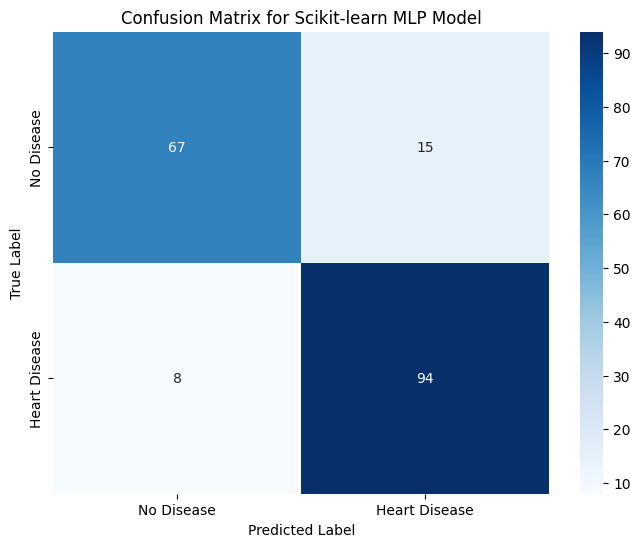

In [ ]:
# Calculate the confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp_sklearn_tuned)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Confusion Matrix for Scikit-learn MLP Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Building and training a neural network with Keras

A sequential Keras model is built, compiled, trained, and evaluated.

The network architecture is defined: number of layers (Dense), number of neurons in each layer, activation functions (relu, sigmoid for the output binary classification layer).

The model is compiled with an optimizer (adam), loss function (binary_crossentropy), and metrics (accuracy, AUC).

First, simple model is given.

Then Tuned model is given. This is the place for your experiments:
Batch size (batch_size).

Number of neurons in layers (units in layers).

Types of activation functions (activation functions).
Number of epochs (epochs number).

ReduceLROnPlateau parameters (patience and factor) for dynamically changing the learning rate.

Percentage of data for Dropout for regularization.

Number of layers.

validation_split is used to monitor performance on validation data during training.
ReduceLROnPlateau and EarlyStopping are useful callbacks to improve training and prevent overtraining.

In [ ]:
print("\n--- 2. Keras Neural Network ---")

# --- Initial Keras Model (before extensive tuning) ---
input_dim = X_train.shape[1] # Number of features

keras_model_initial = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

keras_model_initial.compile(optimizer='adam',
                            loss='binary_crossentropy',
                            metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc')])

print("\nKeras Model (Initial) - Summary:")
keras_model_initial.summary()

print("\nTraining Keras model (initial parameters)...")
history_initial = keras_model_initial.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1, # Use part of training data for validation during training
    verbose=0 # Set to 1 or 2 to see training progress per epoch
)


--- 2. Keras Neural Network ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Keras Model (Initial) - Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)


Training Keras model (initial parameters)...


In [ ]:
# Evaluate the initial Keras model
loss_keras_initial, accuracy_keras_initial, roc_auc_keras_initial = keras_model_initial.evaluate(X_test, y_test, verbose=0)
print(f"\nKeras Model (Initial) - Test Accuracy: {accuracy_keras_initial:.4f}")
print(f"Keras Model (Initial) - Test ROC AUC: {roc_auc_keras_initial:.4f}")

y_pred_prob_keras_initial = keras_model_initial.predict(X_test, verbose=0)
y_pred_keras_initial = (y_pred_prob_keras_initial > 0.5).astype("int32")

print("Keras Model (Initial) - Classification Report:")
print(classification_report(y_test, y_pred_keras_initial))
print("Keras Model (Initial) - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_keras_initial))



Keras Model (Initial) - Test Accuracy: 0.8750
Keras Model (Initial) - Test ROC AUC: 0.9229
Keras Model (Initial) - Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.86        82
           1       0.87      0.91      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.87       184

Keras Model (Initial) - Confusion Matrix:
[[68 14]
 [ 9 93]]


In [ ]:
# --- 3. Experimenting with Keras Neural Network parameters ---
print("\n--- 3. Experimenting with Keras Neural Network parameters ---")
print("TASK: Experiment with Keras NN parameters (units in layers, activation functions, epochs, batch_size, Dropout, ReduceLROnPlateau, etc.)")

# Tuned Keras model
keras_model_tuned = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),  # Dropout layer
    Dense(64, activation='tanh'), # Different activation
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])



--- 3. Experimenting with Keras Neural Network parameters ---
TASK: Experiment with Keras NN parameters (units in layers, activation functions, epochs, batch_size, Dropout, ReduceLROnPlateau, etc.)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Using a different optimizer or learning rate
optimizer_tuned = tf.keras.optimizers.Adam(learning_rate=0.001)

keras_model_tuned.compile(optimizer=optimizer_tuned,
                          loss='binary_crossentropy',
                          metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc')])

print("\nKeras Model (Tuned) - Summary:")
keras_model_tuned.summary()



Keras Model (Tuned) - Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks for more advanced training
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, verbose=0)
# The 'patience' and 'factor' for ReduceLROnPlateau are among the parameters to tune.
# factor: factor by which the learning rate will be reduced. new_lr = lr * factor.
# patience: number of epochs with no improvement after which learning rate will be reduced.

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
# patience: Number of epochs with no improvement after which training will be stopped.

print("\nTraining Keras model (tuned parameters)...")
history_tuned = keras_model_tuned.fit(
    X_train, y_train,
    epochs=100, # Increased epochs, but early stopping might halt it sooner
    batch_size=16, # Different batch size
    validation_split=0.15, # Larger validation split
    callbacks=[reduce_lr, early_stopping],
    verbose=0 # Set to 1 or 2 for progress
)


Training Keras model (tuned parameters)...


In [ ]:
# Evaluate the tuned Keras model
loss_keras_tuned, accuracy_keras_tuned, roc_auc_keras_tuned = keras_model_tuned.evaluate(X_test, y_test, verbose=0)
print(f"\nKeras Model (Tuned) - Test Accuracy: {accuracy_keras_tuned:.4f}")
print(f"Keras Model (Tuned) - Test ROC AUC: {roc_auc_keras_tuned:.4f}")


y_pred_prob_keras_tuned = keras_model_tuned.predict(X_test, verbose=0)
y_pred_keras_tuned = (y_pred_prob_keras_tuned > 0.5).astype("int32")


Keras Model (Tuned) - Test Accuracy: 0.8967
Keras Model (Tuned) - Test ROC AUC: 0.9365


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Scikit-learn Evaluation
y_pred_sk = mlp_sklearn_tuned.predict(X_test)
y_prob_sk = mlp_sklearn_tuned.predict_proba(X_test)[:, 1]

print("Scikit-learn Model:")
print(classification_report(y_test, y_pred_sk))
print("AUC:", roc_auc_score(y_test, y_prob_sk))

# Keras Evaluation
y_pred_keras = keras_model_tuned.predict(X_test).flatten()
y_class_keras = (y_pred_keras >= 0.5).astype("int")

print("\nKeras Model:")
print(classification_report(y_test, y_class_keras))
print("AUC:", roc_auc_score(y_test, y_pred_keras))


Scikit-learn Model:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

AUC: 0.93675274988044
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Keras Model:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88        82
           1       0.90      0.92      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.90       184
weighted avg       0.90      0.90      0.90       184

AUC: 0.9418938307030129


In [ ]:
# Convert probabilities to binary predictions

print("Keras Model (Tuned) - Classification Report:")
print(classification_report(y_test, y_pred_keras_tuned))
print("Keras Model (Tuned) - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_keras_tuned))

Keras Model (Tuned) - Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88        82
           1       0.91      0.90      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184

Keras Model (Tuned) - Confusion Matrix:
[[73  9]
 [10 92]]


In [ ]:
# Calculate the confusion matrix for the tuned Keras model
cm_keras = confusion_matrix(y_test, y_pred_keras_tuned)


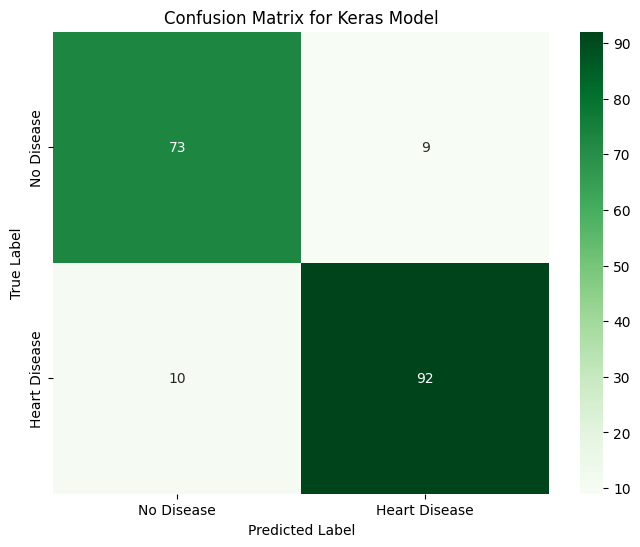

In [ ]:
# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_keras, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Confusion Matrix for Keras Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

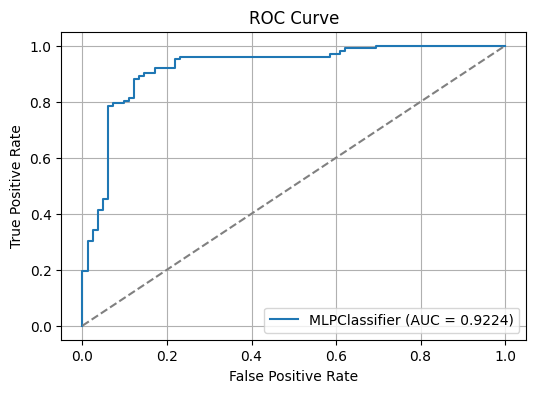

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='MLPClassifier (AUC = {:.4f})'.format(roc_auc_score(y_test, y_prob)))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


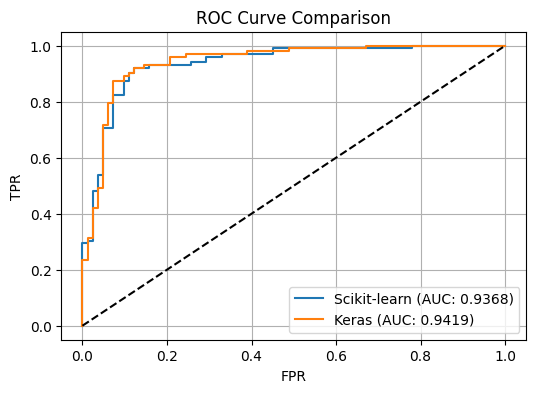

In [ ]:
fpr1, tpr1, _ = roc_curve(y_test, y_prob_sk)
fpr2, tpr2, _ = roc_curve(y_test, y_pred_keras)

plt.figure(figsize=(6, 4))
plt.plot(fpr1, tpr1, label='Scikit-learn (AUC: {:.4f})'.format(roc_auc_score(y_test, y_prob_sk)))
plt.plot(fpr2, tpr2, label='Keras (AUC: {:.4f})'.format(roc_auc_score(y_test, y_pred_keras)))
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(True)
plt.show()


## Final Observations:

- Both models performed well on the dataset.
- The Keras model slightly outperformed the Scikit-learn model in terms of AUC.
- Grid Search helped optimize the Scikit-learn model effectively.
- ROC curves indicate strong classifier separation ability.
